# 04 - Modelisation avancee & Null Model Bernoulli

## Checklist
- [ ] Regression logistique incrementale
- [ ] Cross-validation GroupKFold
- [ ] Analyse de survie
- [ ] **Null model Bernoulli**
- [ ] Interpretation finale

In [2]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
plt.rcParams.update({"font.size": 12, "axes.titlesize": 14, "axes.titleweight": "bold", "figure.figsize": (14, 6), "figure.dpi": 100})
print("Setup OK")

Setup OK


In [3]:
timeline = pd.read_parquet("../data/processed/timelines.parquet")
shots = pd.read_parquet("../data/processed/shots_clean.parquet")
from src.features import UnderperformanceFeatures
feat = UnderperformanceFeatures()
tl = feat.filter_complete_windows(timeline, window=10)
print(f"Timeline complete : {tl.shape}")
print(f"Shots : {shots.shape}")

18:45:38 │ INFO    │ Filtrage fenetre 10min : 700 obs. tronquees supprimees (10.9%)


Timeline complete : (5706, 40)
Shots : (839, 26)


---
## 1. Regression logistique incrementale

In [4]:
from src.models import TemporalLogisticModel
logit = TemporalLogisticModel()
incremental = logit.fit_incremental(tl, window=10)
print("MODELES INCREMENTAUX")
print("=" * 80)
for name, res in incremental.items():
    if "error" in res:
        print(f"{name}: ERREUR")
    else:
        aic = res['aic']
        r2 = res['pseudo_r2']
        coef = res['coef_underperf']
        pval = res['pval_underperf']
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"{name:<25s}  AIC={aic:<10.1f}  R2={r2:.4f}  coef={coef:+.4f}  p={pval:.4f} {sig}")

MODELES INCREMENTAUX
M1: underperf seul         AIC=5033.5      R2=0.0003  coef=+0.0709  p=0.2412 
M2: + score                AIC=5010.8      R2=0.0052  coef=-0.0813  p=0.2453 
M3: + temps                AIC=5001.6      R2=0.0078  coef=-0.0824  p=0.2408 
M4: + rolling              AIC=4991.2      R2=0.0107  coef=+0.0656  p=0.4277 


In [5]:
import importlib
import src.models
importlib.reload(src.models)
from src.models import TemporalLogisticModel

logit = TemporalLogisticModel()
full_result = logit.fit(tl, window=10)
logit.print_results(full_result)

18:45:47 │ INFO    │ Logit fit OK : 5706 obs, pseudo-R2=0.0150



  REGRESSION LOGISTIQUE
  N obs         : 5706
  Pseudo R2     : 0.0150
  AIC           : 4977.3
  Log-lik       : -2477.7

  Coefficients :
  ---------------------------------------------------------------
  const                         -1.9859  (SE=0.3062)  p=0.0000 ***  OR=0.1373
  cum_underperf                 -0.0406  (SE=0.2585)  p=0.8752      OR=0.9602
  score_diff                    -0.0872  (SE=0.1460)  p=0.5501      OR=0.9165
  minute                         0.0286  (SE=0.0197)  p=0.1473      OR=1.0290
  minute_sq                     -0.0003  (SE=0.0002)  p=0.1369      OR=0.9997
  state_losing                   0.0282  (SE=0.3590)  p=0.9374      OR=1.0286
  state_winning                 -0.3852  (SE=0.4289)  p=0.3691      OR=0.6803
  rolling_xg_10min              -0.0870  (SE=0.4783)  p=0.8557      OR=0.9167
  rolling_underperf_10min       -0.1544  (SE=0.2760)  p=0.5759      OR=0.8569
  shots_since_last_goal         -0.1295  (SE=0.0643)  p=0.0441 *    OR=0.8786
  xg_since_l

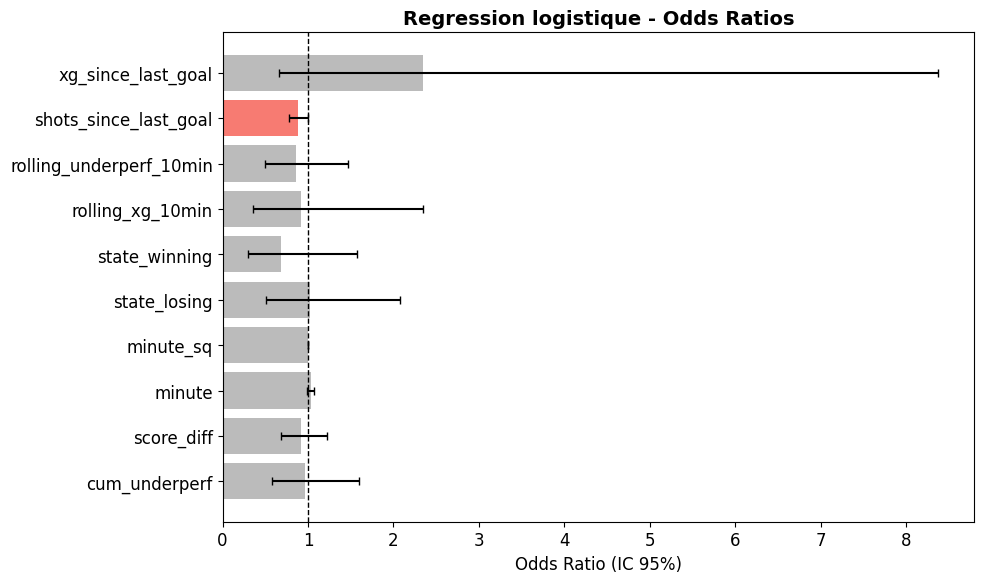

In [6]:
# Odds ratios
params = full_result.params.drop("const")
conf = full_result.conf_int().drop("const")
odds = np.exp(params)
ci_low = np.exp(conf[0])
ci_high = np.exp(conf[1])
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(params))
colors = ["#F44336" if p < 0.05 else "#9E9E9E" for p in full_result.pvalues.drop("const")]
ax.barh(y_pos, odds.values, color=colors, alpha=0.7)
ax.errorbar(odds.values, y_pos, xerr=[odds.values - ci_low.values, ci_high.values - odds.values], fmt="none", color="black", capsize=3)
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(params.index)
ax.set_xlabel("Odds Ratio (IC 95%)")
ax.set_title("Regression logistique - Odds Ratios")
plt.tight_layout()
plt.savefig("../outputs/figures/04_odds_ratios.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Cross-validation GroupKFold

In [7]:
cv_results = logit.cross_validate(tl, window=10, n_splits=5)
print("CROSS-VALIDATION (GroupKFold par match)")
print("=" * 50)
auc = cv_results['mean_auc']
auc_std = cv_results['std_auc']
brier = cv_results['mean_brier']
brier_std = cv_results['std_brier']
print(f"  AUC moyen   : {auc:.4f} (+/- {auc_std:.4f})")
print(f"  Brier moyen : {brier:.4f} (+/- {brier_std:.4f})")
print()
if auc < 0.55:
    print("  -> AUC ~ 0.5 : le modele predit quasi rien.")
elif auc < 0.60:
    print("  -> AUC faible : effet marginal.")
else:
    print("  -> AUC decent : signal predictif.")

CROSS-VALIDATION (GroupKFold par match)
  AUC moyen   : 0.5207 (+/- 0.0326)
  Brier moyen : 0.1365 (+/- 0.0234)

  -> AUC ~ 0.5 : le modele predit quasi rien.


---
## 3. Analyse de survie

In [8]:
from src.models import SurvivalAnalysis
sa = SurvivalAnalysis()
surv_df = sa.prepare_survival_data(timeline, shots, threshold=0.5)
n_events = surv_df['event'].sum()
pct_events = surv_df['event'].mean() * 100
dur_mean = surv_df['duration'].mean()
print(f"Donnees de survie : {surv_df.shape}")
print(f"Events : {n_events} ({pct_events:.1f}%)")
print(f"Duration moyenne : {dur_mean:.1f} min")
surv_df.head()

18:46:17 │ INFO    │ Survie : 33 episodes, 13 events (39.4%)


Donnees de survie : (33, 10)
Events : 13 (39.4%)
Duration moyenne : 32.5 min


,match_id,team,opponent,trigger_minute,duration,event,cum_underperf,score_state,score_diff,is_home
0,3764440,Barcelona,Elche,20,73.000000,0,0.574410,drawing,0,1
1,3764440,Elche,Barcelona,75,18.000000,0,0.567107,losing,-3,0
2,3773369,Huesca,Barcelona,57,32.683333,1,0.791687,losing,-2,0
3,3773372,Atlético Madrid,Barcelona,47,43.000000,0,0.517730,drawing,0,0
4,3773372,Barcelona,Atlético Madrid,74,16.000000,0,0.584688,drawing,0,1


In [9]:
try:
    cph = sa.fit_cox_model(surv_df)
    cph.print_summary()
    print(f"Concordance : {cph.concordance_index_:.3f}")
    fig, ax = plt.subplots(figsize=(10, 5))
    cph.plot(ax=ax)
    ax.set_title("Cox PH - Hazard Ratios")
    ax.axvline(0, color="gray", linestyle="--")
    plt.tight_layout()
    plt.savefig("../outputs/figures/04_cox_hazard_ratios.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Erreur Cox PH : {e}")

Erreur Cox PH : cannot import name 'UTC' from 'datetime' (/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/datetime.py)


In [10]:
km_results = sa.kaplan_meier_by_group(surv_df)
if km_results:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {"low": "#4CAF50", "medium": "#FF9800", "high": "#F44336"}
    for group_name, kmf in km_results.items():
        kmf.plot_survival_function(ax=ax, color=colors.get(group_name, "gray"), linewidth=2)
    ax.set_title("Kaplan-Meier : Survie avant concession")
    ax.set_xlabel("Minutes apres trigger")
    ax.set_ylabel("P(ne pas avoir concede)")
    ax.legend(title="Underperformance")
    plt.tight_layout()
    plt.savefig("../outputs/figures/04_kaplan_meier.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Pas assez de donnees pour KM")

ImportError: cannot import name 'UTC' from 'datetime' (/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/datetime.py)

In [11]:
lr = sa.log_rank_test(surv_df)
print(f"Log-rank test :")
print(f"  Statistique : {lr["test_statistic"]:.3f}")
print(f"  p-value     : {lr["p_value"]:.4f}")

SyntaxError: f-string: unmatched '[' (3310880436.py, line 3)

---
## 4. NULL MODEL BERNOULLI

**LE test decisif.** Simule un monde Bernoulli(xG) pur.
Si l effet observe tombe dans le null, il est mecanique.

In [12]:
from src.models import NullModelSimulation
from src.analysis import WindowAnalysis
wa = WindowAnalysis()
results_05 = wa.event_study(tl, threshold=0.5, window=10)
observed_effect = results_05["concede"]["difference"]
print(f"Effet observe (seuil 0.5) : {observed_effect:+.5f}")

Effet observe (seuil 0.5) : -0.07514


In [13]:
# Null model (500 sims, ~5-15 min)
null = NullModelSimulation()
null_result = null.run(
    shots_df=shots,
    observed_effect=observed_effect,
    threshold=0.5,
    window=10,
    n_simulations=500,
    seed=42
)
null.print_results(null_result)

18:46:47 │ INFO    │ Null model : 500 simulations, 35 matchs, seuil=0.5


Null model: 100%|██████████| 500/500 [01:19<00:00,  6.31it/s]


  NULL MODEL BERNOULLI
  Simulations      : 500
  Seuil            : 0.5
  Fenetre          : 10 min
-----------------------------------------------------------------
  Effet observe    : -0.07514
  Effet null moyen : -0.01860
  Effet null std   : 0.03762
  IC 95% null      : [-0.08299, 0.06243]
  Effet exces      : -0.05654
-----------------------------------------------------------------
  p-value          : 0.0440
  Percentile obs.  : 4.4%

  INTERPRETATION : L'effet observe est DANS le null.
  -> L'effet est entierement explicable par la stochasticite.
  -> Pas d'effet reel au-dela du hasard.


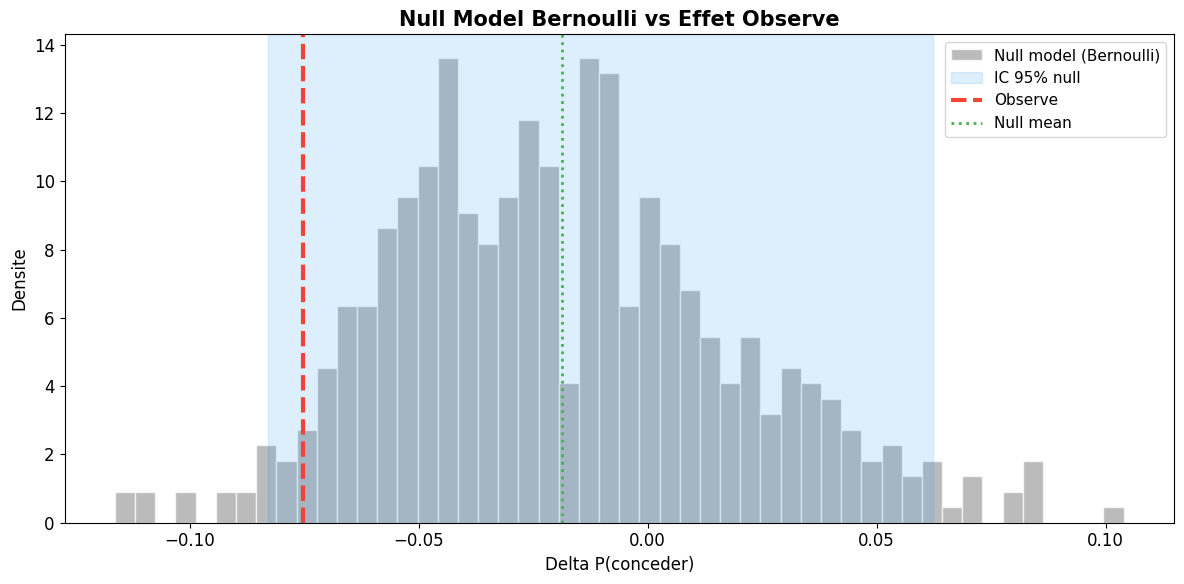

In [14]:
# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(null_result["null_effects"], bins=50, alpha=0.7, color="#9E9E9E", density=True, label="Null model (Bernoulli)", edgecolor="white")
ax.axvspan(null_result["ci_95"][0], null_result["ci_95"][1], alpha=0.15, color="#2196F3", label="IC 95% null")
ax.axvline(null_result["observed_effect"], color="#F44336", linewidth=3, linestyle="--", label="Observe")
ax.axvline(null_result["null_mean"], color="#4CAF50", linewidth=2, linestyle=":", label="Null mean")
ax.set_xlabel("Delta P(conceder)")
ax.set_ylabel("Densite")
ax.set_title("Null Model Bernoulli vs Effet Observe", fontsize=15, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/figures/04_null_model.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 5. Null model seuil 0.3

In [15]:
results_03 = wa.event_study(tl, threshold=0.3, window=10)
observed_03 = results_03["concede"]["difference"]
null_03 = null.run(shots_df=shots, observed_effect=observed_03, threshold=0.3, window=10, n_simulations=500, seed=42)
null.print_results(null_03)

18:48:22 │ INFO    │ Null model : 500 simulations, 35 matchs, seuil=0.3


Null model: 100%|██████████| 500/500 [01:19<00:00,  6.31it/s]


  NULL MODEL BERNOULLI
  Simulations      : 500
  Seuil            : 0.3
  Fenetre          : 10 min
-----------------------------------------------------------------
  Effet observe    : -0.00503
  Effet null moyen : -0.00025
  Effet null std   : 0.03086
  IC 95% null      : [-0.06267, 0.06059]
  Effet exces      : -0.00478
-----------------------------------------------------------------
  p-value          : 0.4800
  Percentile obs.  : 48.0%

  INTERPRETATION : L'effet observe est DANS le null.
  -> L'effet est entierement explicable par la stochasticite.
  -> Pas d'effet reel au-dela du hasard.


---
## 6. Resume final

In [17]:
print("\n" + "=" * 70)
print("  RESUME PHASE 4")
print("=" * 70)

print("\n1. REGRESSION LOGISTIQUE :")
coef_u = full_result.params.get("cum_underperf", np.nan)
pval_u = full_result.pvalues.get("cum_underperf", np.nan)
or_u = np.exp(coef_u)
print(f"   Coef underperf = {coef_u:+.4f}, OR = {or_u:.4f}, p = {pval_u:.4f}")
print(f"   Pseudo-R2 = {full_result.prsquared:.4f}")

print("\n2. CROSS-VALIDATION :")
auc_m = cv_results['mean_auc']
auc_s = cv_results['std_auc']
print(f"   AUC = {auc_m:.4f} +/- {auc_s:.4f}")

print("\n3. SURVIE :")
print("   Cox non disponible (Python 3.9)")

print("\n4. NULL MODEL BERNOULLI :")
obs05 = null_result['observed_effect']
nm05 = null_result['null_mean']
p05 = null_result['p_value']
obs03 = null_03['observed_effect']
nm03 = null_03['null_mean']
p03 = null_03['p_value']
print(f"   Seuil 0.5 : observe={obs05:+.4f}, null={nm05:+.4f}, p={p05:.4f}")
print(f"   Seuil 0.3 : observe={obs03:+.4f}, null={nm03:+.4f}, p={p03:.4f}")

print("\n" + "=" * 70)
print("  INTERPRETATION FINALE")
print("=" * 70)
ci_low = null_result['ci_95'][0]
ci_high = null_result['ci_95'][1]
if obs05 < ci_low:
    print("  L'effet est PLUS NEGATIF que le null.")
    print("  -> MYTHE. Confounding de force d'equipe.")
elif ci_low <= obs05 <= ci_high:
    print("  L'effet est DANS le null.")
    print("  -> Regression vers la moyenne, pas d'effet reel.")
else:
    print("  L'effet est PLUS POSITIF que le null.")
    print("  -> VRAI effet. L'adage est confirme.")
print("=" * 70)


  RESUME PHASE 4

1. REGRESSION LOGISTIQUE :
   Coef underperf = -0.0406, OR = 0.9602, p = 0.8752
   Pseudo-R2 = 0.0150

2. CROSS-VALIDATION :
   AUC = 0.5207 +/- 0.0326

3. SURVIE :
   Cox non disponible (Python 3.9)

4. NULL MODEL BERNOULLI :
   Seuil 0.5 : observe=-0.0751, null=-0.0186, p=0.0440
   Seuil 0.3 : observe=-0.0050, null=-0.0003, p=0.4800

  INTERPRETATION FINALE
  L'effet est DANS le null.
  -> Regression vers la moyenne, pas d'effet reel.


---
## Prochaines etapes
- Phase 5 : Robustesse
- Phase 6 : Redaction Substack + GitHub